<a href="https://colab.research.google.com/github/Jaypatil17/Oasis-Infobyte-Internship/blob/main/Oasis_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


print(' Retail Sales EDA Started')
print(' Files: retail_sales_dataset.csv (main) + menu.csv')

# 1. DATA LOADING & CLEANING [file:38][file:37]
df = pd.read_csv('/bin/retail_sales_dataset.csv')

print(f'\n Dataset shape: {df.shape}')
print('\n Columns:', df.columns.tolist())
print('\nFirst 3 rows:')
print(df.head(3))

# Clean data
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Add features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['MonthName'] = df['Date'].dt.month_name()

print(f'\n Data cleaned: {df.shape[0]} rows remaining')

 Retail Sales EDA Started
 Files: retail_sales_dataset.csv (main) + menu.csv

 Dataset shape: (1000, 9)

 Columns: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

First 3 rows:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  

 Data cleaned: 1000 rows remaining


In [6]:
# 2. DESCRIPTIVE STATISTICS
numeric_cols = ['Quantity', 'Price per Unit', 'Total Amount', 'Age']

print(' DESCRIPTIVE STATISTICS')
stats = df[numeric_cols].describe()
print(stats.round(2))

print('\n Additional Stats:')
for col in numeric_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'None'
    std_val = df[col].std()
    print(f'{col}: Mean={mean_val:.2f}, Median={median_val:.2f}, Mode={mode_val}, Std={std_val:.2f}')

 DESCRIPTIVE STATISTICS
       Quantity  Price per Unit  Total Amount      Age
count   1000.00         1000.00        1000.0  1000.00
mean       2.51          179.89         456.0    41.39
std        1.13          189.68         560.0    13.68
min        1.00           25.00          25.0    18.00
25%        1.00           30.00          60.0    29.00
50%        3.00           50.00         135.0    42.00
75%        4.00          300.00         900.0    53.00
max        4.00          500.00        2000.0    64.00

 Additional Stats:
Quantity: Mean=2.51, Median=3.00, Mode=4, Std=1.13
Price per Unit: Mean=179.89, Median=50.00, Mode=50, Std=189.68
Total Amount: Mean=456.00, Median=135.00, Mode=50, Std=560.00
Age: Mean=41.39, Median=42.00, Mode=43, Std=13.68



 TIME SERIES ANALYSIS


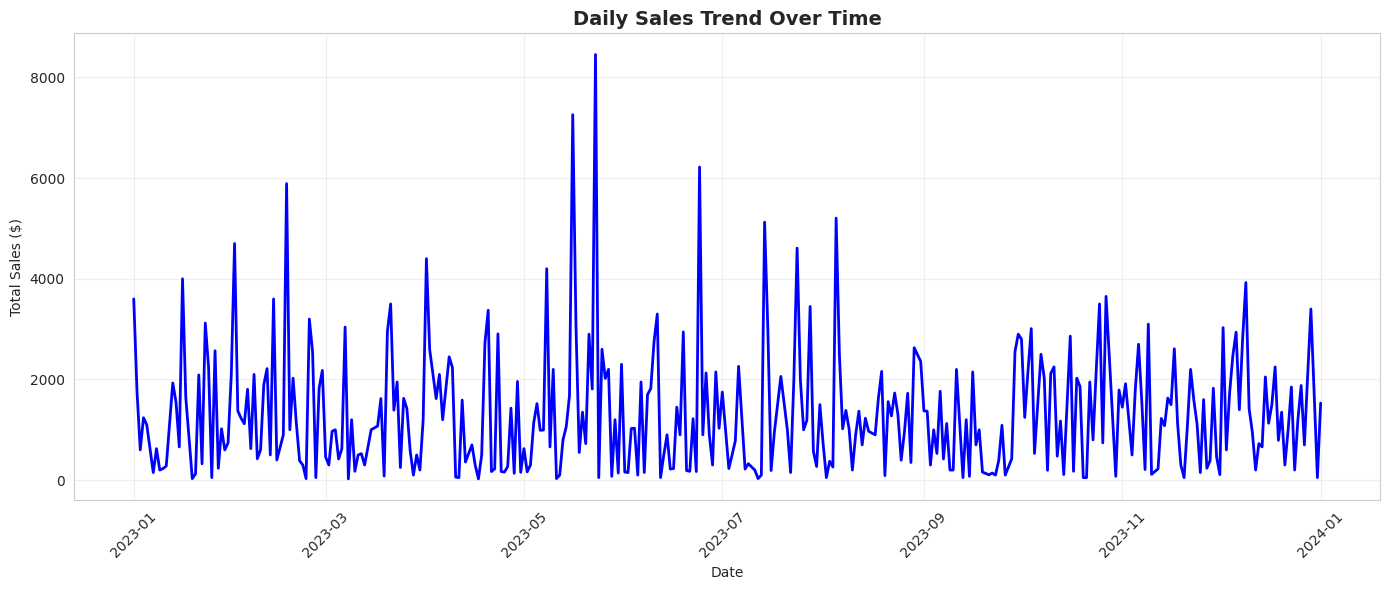

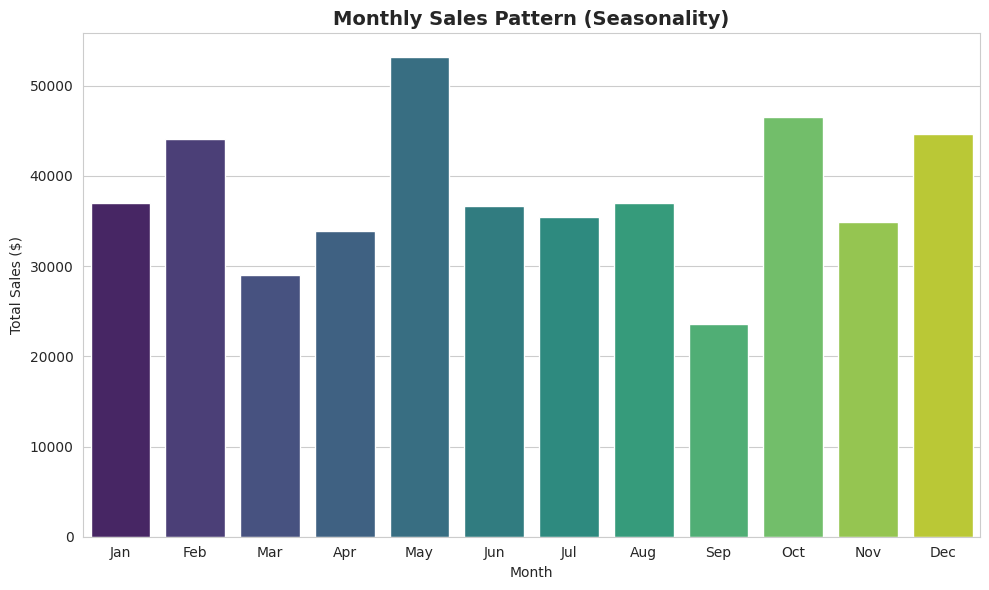

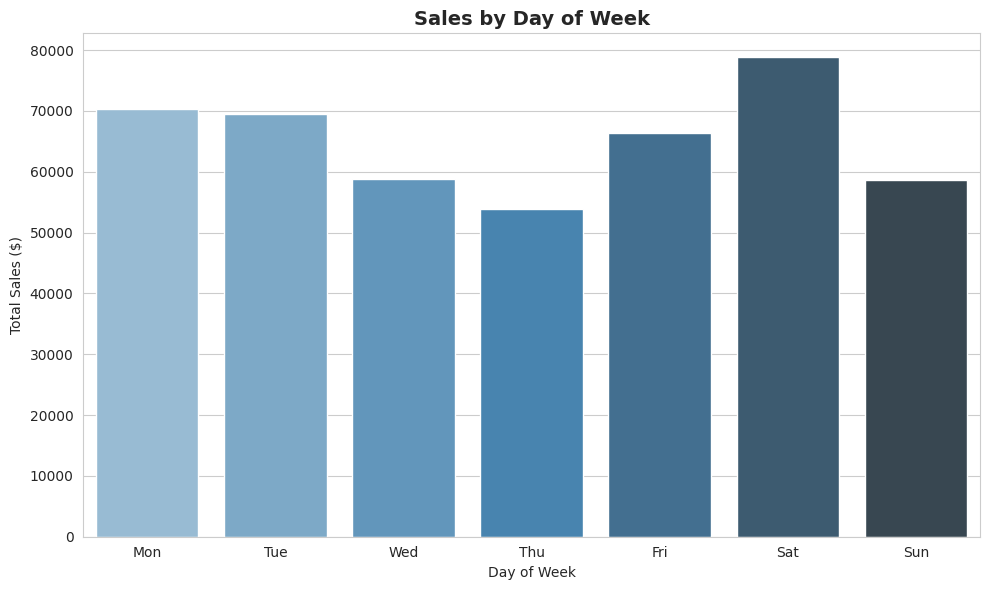

In [7]:
# 3. TIME SERIES ANALYSIS
print('\n TIME SERIES ANALYSIS')

# Daily sales
daily_sales = df.groupby('Date')['Total Amount'].sum().reset_index()
monthly_sales = df.groupby('Month')['Total Amount'].sum()
weekly_sales = df.groupby('DayOfWeek')['Total Amount'].sum()

# Plot 1: Daily Sales Trend (Line Plot)
plt.figure(figsize=(14, 6))
plt.plot(daily_sales['Date'], daily_sales['Total Amount'], linewidth=2, color='blue')
plt.title('Daily Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Monthly Sales (Bar Chart)
plt.figure(figsize=(10, 6))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette='viridis')
plt.title('Monthly Sales Pattern (Seasonality)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(ticks=range(12), labels=months)
plt.tight_layout()
plt.show()

# Plot 3: Weekly Sales Pattern
plt.figure(figsize=(10, 6))
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.barplot(x=weekly_sales.index, y=weekly_sales.values, palette='Blues_d')
plt.title('Sales by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales ($)')
plt.xticks(ticks=range(7), labels=days)
plt.tight_layout()
plt.show()


 CUSTOMER ANALYSIS
 Gender distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64

 Age distribution:
Age range: 18 - 64
Average age: 41.4


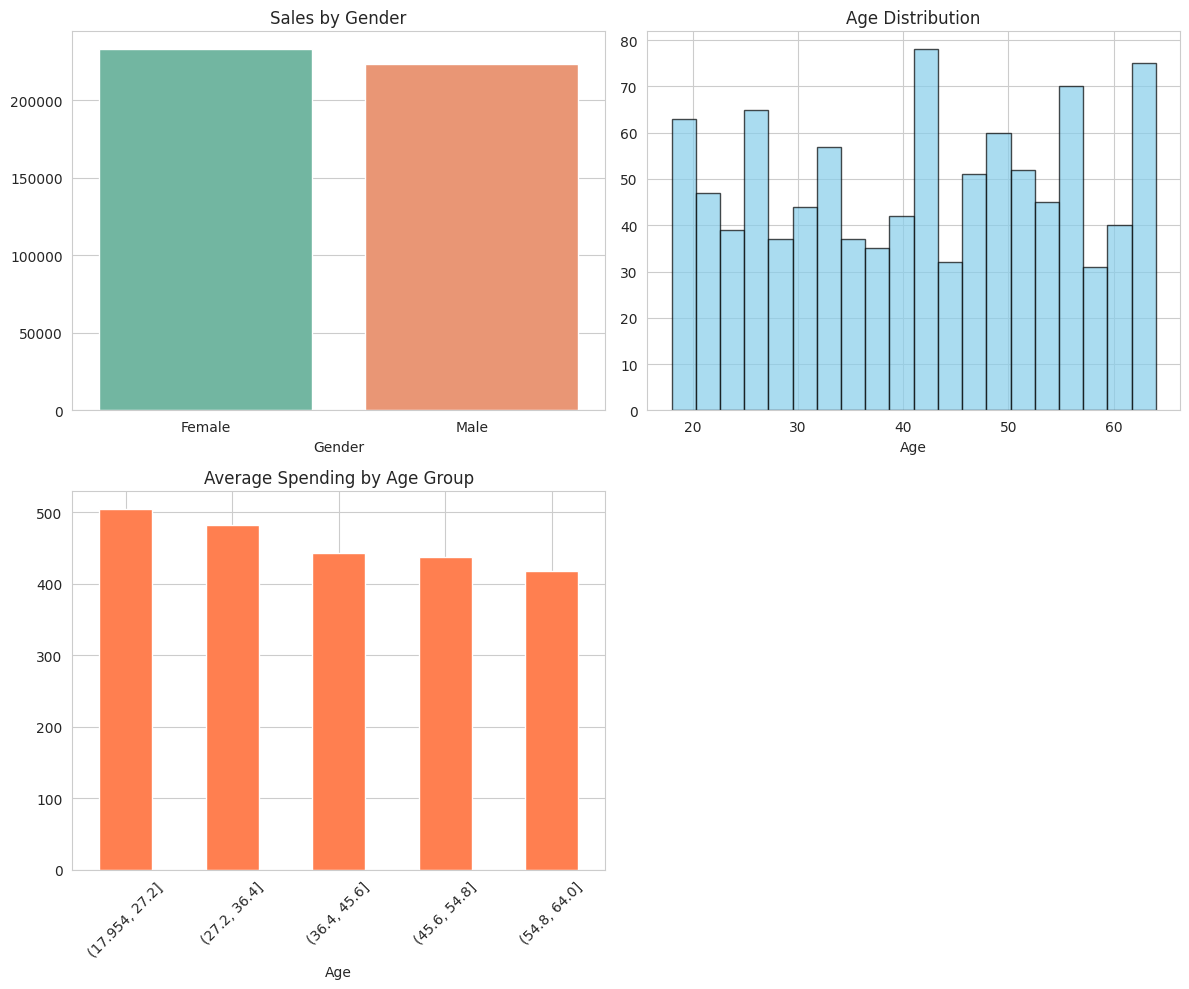


 PRODUCT ANALYSIS
Top 3 Product Categories by Sales:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


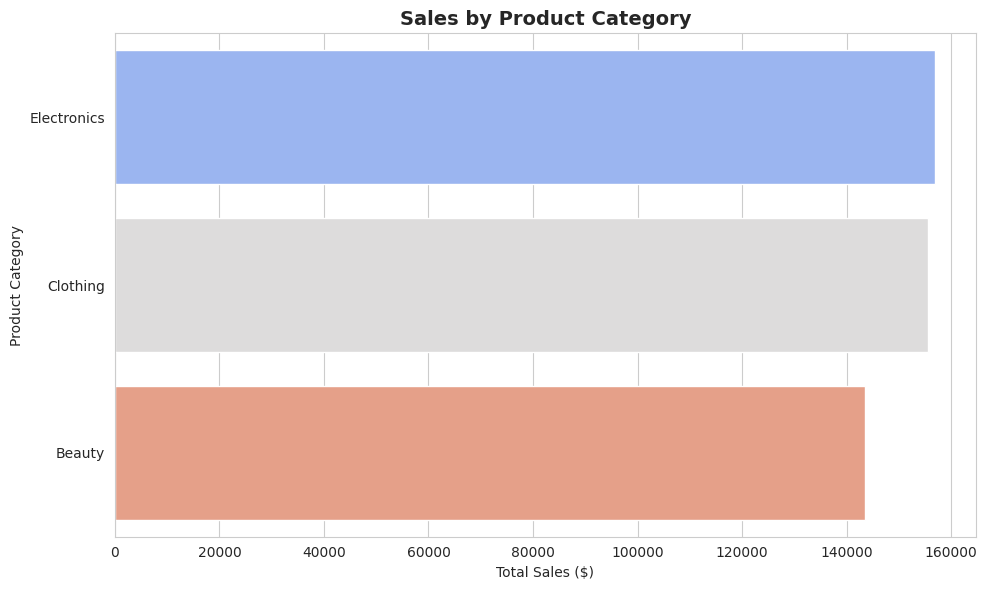

In [8]:
# 4. CUSTOMER & PRODUCT ANALYSIS
print('\n CUSTOMER ANALYSIS')
print(' Gender distribution:')
print(df['Gender'].value_counts())

print('\n Age distribution:')
print('Age range:', df['Age'].min(), '-', df['Age'].max())
print('Average age:', df['Age'].mean().round(1))

# Customer Demographics
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
gender_sales = df.groupby('Gender')['Total Amount'].sum()
sns.barplot(x=gender_sales.index, y=gender_sales.values, palette='Set2')
plt.title('Sales by Gender')

plt.subplot(2, 2, 2)
plt.hist(df['Age'], bins=20, edgecolor='black', color='skyblue', alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')

plt.subplot(2, 2, 3)
age_spending = df.groupby(pd.cut(df['Age'], bins=5))['Total Amount'].mean()
age_spending.plot(kind='bar', color='coral')
plt.title('Average Spending by Age Group')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print('\n PRODUCT ANALYSIS')
print('Top 3 Product Categories by Sales:')
prod_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print(prod_sales.head(3))

# Product Category Sales
plt.figure(figsize=(10, 6))
sns.barplot(x=prod_sales.values, y=prod_sales.index, palette='coolwarm')
plt.title('Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


 ADVANCED VISUALIZATIONS


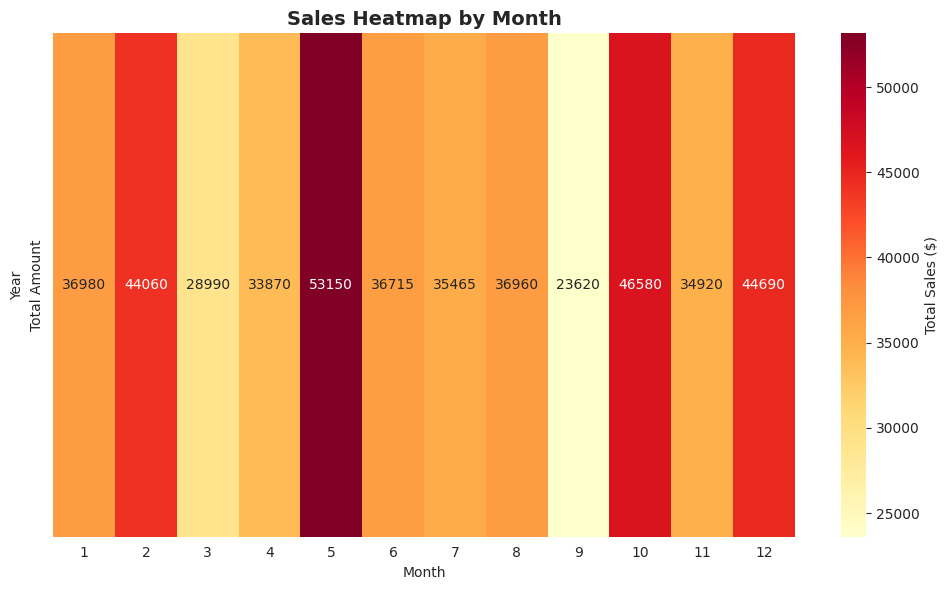

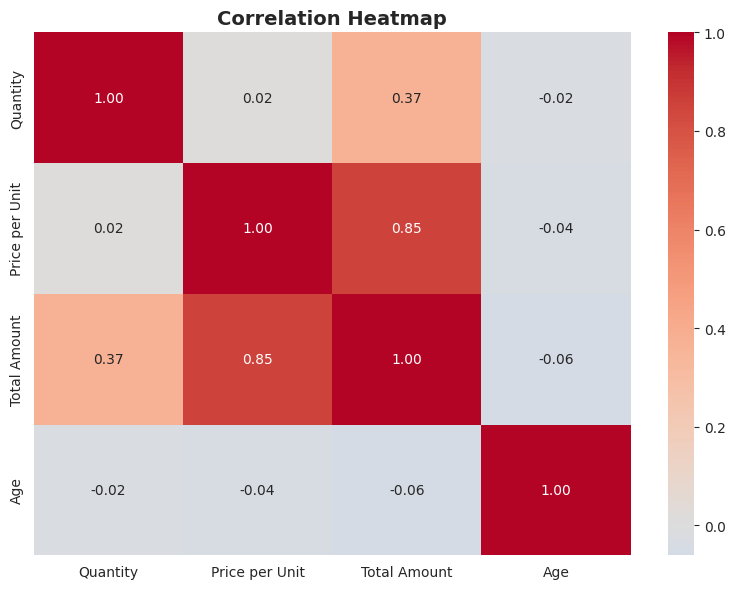

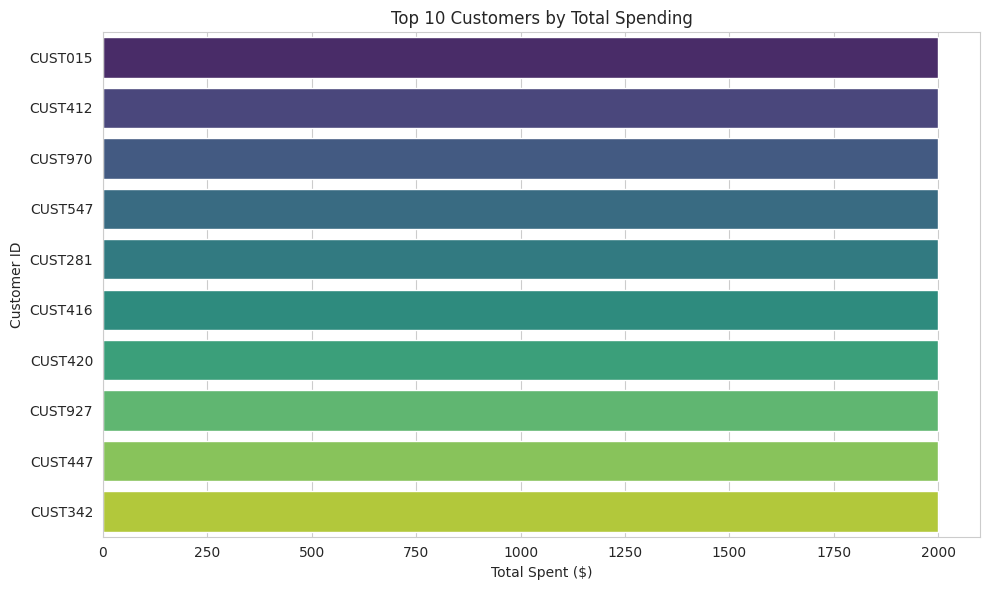

In [9]:
# 5. VISUALIZATIONS (Bar, Line, Heatmap)
print('\n ADVANCED VISUALIZATIONS')

# Heatmap: Sales by Month & Year
pivot_monthly = df.pivot_table(
    index='Month',
    values='Total Amount',
    aggfunc='sum',
    fill_value=0
)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_monthly.T, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Total Sales ($)'})
plt.title('Sales Heatmap by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_cols = ['Quantity', 'Price per Unit', 'Total Amount', 'Age']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top Customers
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='viridis')
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Total Spent ($)')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

In [11]:
# 6. ACTIONABLE RECOMMENDATIONS
print('\n' + '='*70)
print(' ACTIONABLE BUSINESS RECOMMENDATIONS')
print('='*70)

# Dynamic insights from data
best_month = df.groupby('Month')['Total Amount'].sum().idxmax()
best_category = df.groupby('Product Category')['Total Amount'].sum().idxmax()
best_gender = df.groupby('Gender')['Total Amount'].sum().idxmax()
peak_day = df.groupby('DayOfWeek')['Total Amount'].sum().idxmax()

print(f' 1. SEASONAL STRATEGY: Focus promotions on {best_month} (peak sales month)')
print(f' 2. PRODUCT FOCUS: Prioritize "{best_category}" - highest revenue generator')
print(f' 3. TARGETED MARKETING: {best_gender}s spend the most - tailor campaigns')
print(f' 4. STAFFING: Increase staff on Day {peak_day+1} (peak sales day)')
print(f' 5. CUSTOMER RETENTION: Top 10 customers drive significant revenue - loyalty program')
print(f' 6. STOCK MANAGEMENT: Monitor "Electronics"/"Clothing" inventory closely')

total_revenue = df['Total Amount'].sum()
avg_order = df['Total Amount'].mean()
print(f'\n KEY METRICS:')
print(f'   Total Revenue: ${total_revenue:,.0f}')
print(f'   Average Order Value: ${avg_order:.2f}')
print(f'   Total Transactions: {len(df)}')



 ACTIONABLE BUSINESS RECOMMENDATIONS
 1. SEASONAL STRATEGY: Focus promotions on 5 (peak sales month)
 2. PRODUCT FOCUS: Prioritize "Electronics" - highest revenue generator
 3. TARGETED MARKETING: Females spend the most - tailor campaigns
 4. STAFFING: Increase staff on Day 6 (peak sales day)
 5. CUSTOMER RETENTION: Top 10 customers drive significant revenue - loyalty program
 6. STOCK MANAGEMENT: Monitor "Electronics"/"Clothing" inventory closely

 KEY METRICS:
   Total Revenue: $456,000
   Average Order Value: $456.00
   Total Transactions: 1000
